# 🏗️ Steel Faults Classification - Comprehensive EDA and Modeling

This notebook covers the Exploratory Data Analysis (EDA), benchmarking, exhaustive hyperparameter tuning for multiple models, and final result analysis for the Steel Faults dataset.

### Problem Description
The goal is to automatically classify defects in steel plates based on various geometric and luminosity attributes. Steel plate production can result in different types of faults, and early detection is crucial for quality control.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import warnings
warnings.filterwarnings('ignore')

# Setting aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

%matplotlib inline

## 1. Data Loading and Initial Inspection

In [2]:
df = pd.read_csv('../data/steel_plates_faults_original_dataset.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1941, 35)


,id,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,0,42,50,270900,270944,267,17,44,24220,76,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,1,645,651,2538079,2538108,108,10,30,11397,84,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,2,829,835,1553913,1553931,71,8,19,7972,99,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,3,853,860,369370,369415,176,13,45,18996,99,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,4,1289,1306,498078,498335,2409,60,260,246930,37,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1941.0,9.700000e+02,5.604628e+02,0.0000,485.0000,9.700000e+02,1.455000e+03,1.940000e+03
X_Minimum,1941.0,5.711360e+02,5.206907e+02,0.0000,51.0000,4.350000e+02,1.053000e+03,1.705000e+03
X_Maximum,1941.0,6.179645e+02,4.976274e+02,4.0000,192.0000,4.670000e+02,1.072000e+03,1.713000e+03
Y_Minimum,1941.0,1.650685e+06,1.774578e+06,6712.0000,471253.0000,1.204128e+06,2.183073e+06,1.298766e+07
Y_Maximum,1941.0,1.650739e+06,1.774590e+06,6724.0000,471281.0000,1.204136e+06,2.183084e+06,1.298769e+07
Pixels_Areas,1941.0,1.893878e+03,5.168460e+03,2.0000,84.0000,1.740000e+02,8.220000e+02,1.526550e+05
X_Perimeter,1941.0,1.118552e+02,3.012092e+02,2.0000,15.0000,2.600000e+01,8.400000e+01,1.044900e+04
Y_Perimeter,1941.0,8.296600e+01,4.264829e+02,1.0000,13.0000,2.500000e+01,8.300000e+01,1.815200e+04
Sum_of_Luminosity,1941.0,2.063121e+05,5.122936e+05,250.0000,9522.0000,1.920200e+04,8.301100e+04,1.159141e+07
Minimum_of_Luminosity,1941.0,8.454869e+01,3.213428e+01,0.0000,63.0000,9.000000e+01,1.060000e+02,2.030000e+02


### Missing Values Check

In [4]:
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print("Missing values summary:")
    print(missing[missing > 0])

No missing values found in the dataset.


## 2. Target Variable Analysis

The dataset contains 7 binary target columns. We will unify them for easier classification tasks.

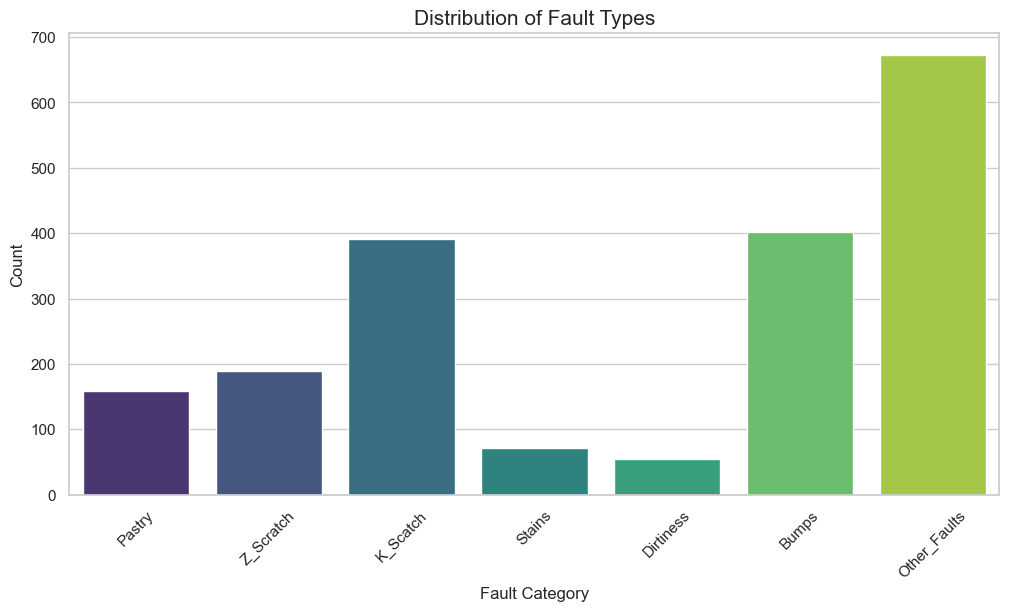

Class distribution percentages:
target_name
Other_Faults    34.672849
Bumps           20.710974
K_Scatch        20.144256
Z_Scratch        9.788769
Pastry           8.140134
Stains           3.709428
Dirtiness        2.833591
Name: proportion, dtype: float64


In [5]:
target_cols = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
df['target'] = np.argmax(df[target_cols].values, axis=1)
df['target_name'] = df['target'].map(lambda x: target_cols[x])

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='target_name', order=target_cols, palette='viridis')
plt.title('Distribution of Fault Types', fontsize=15)
plt.xlabel('Fault Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print("Class distribution percentages:")
print(df['target_name'].value_counts(normalize=True) * 100)

## 3. Detailed Exploratory Data Analysis (EDA)

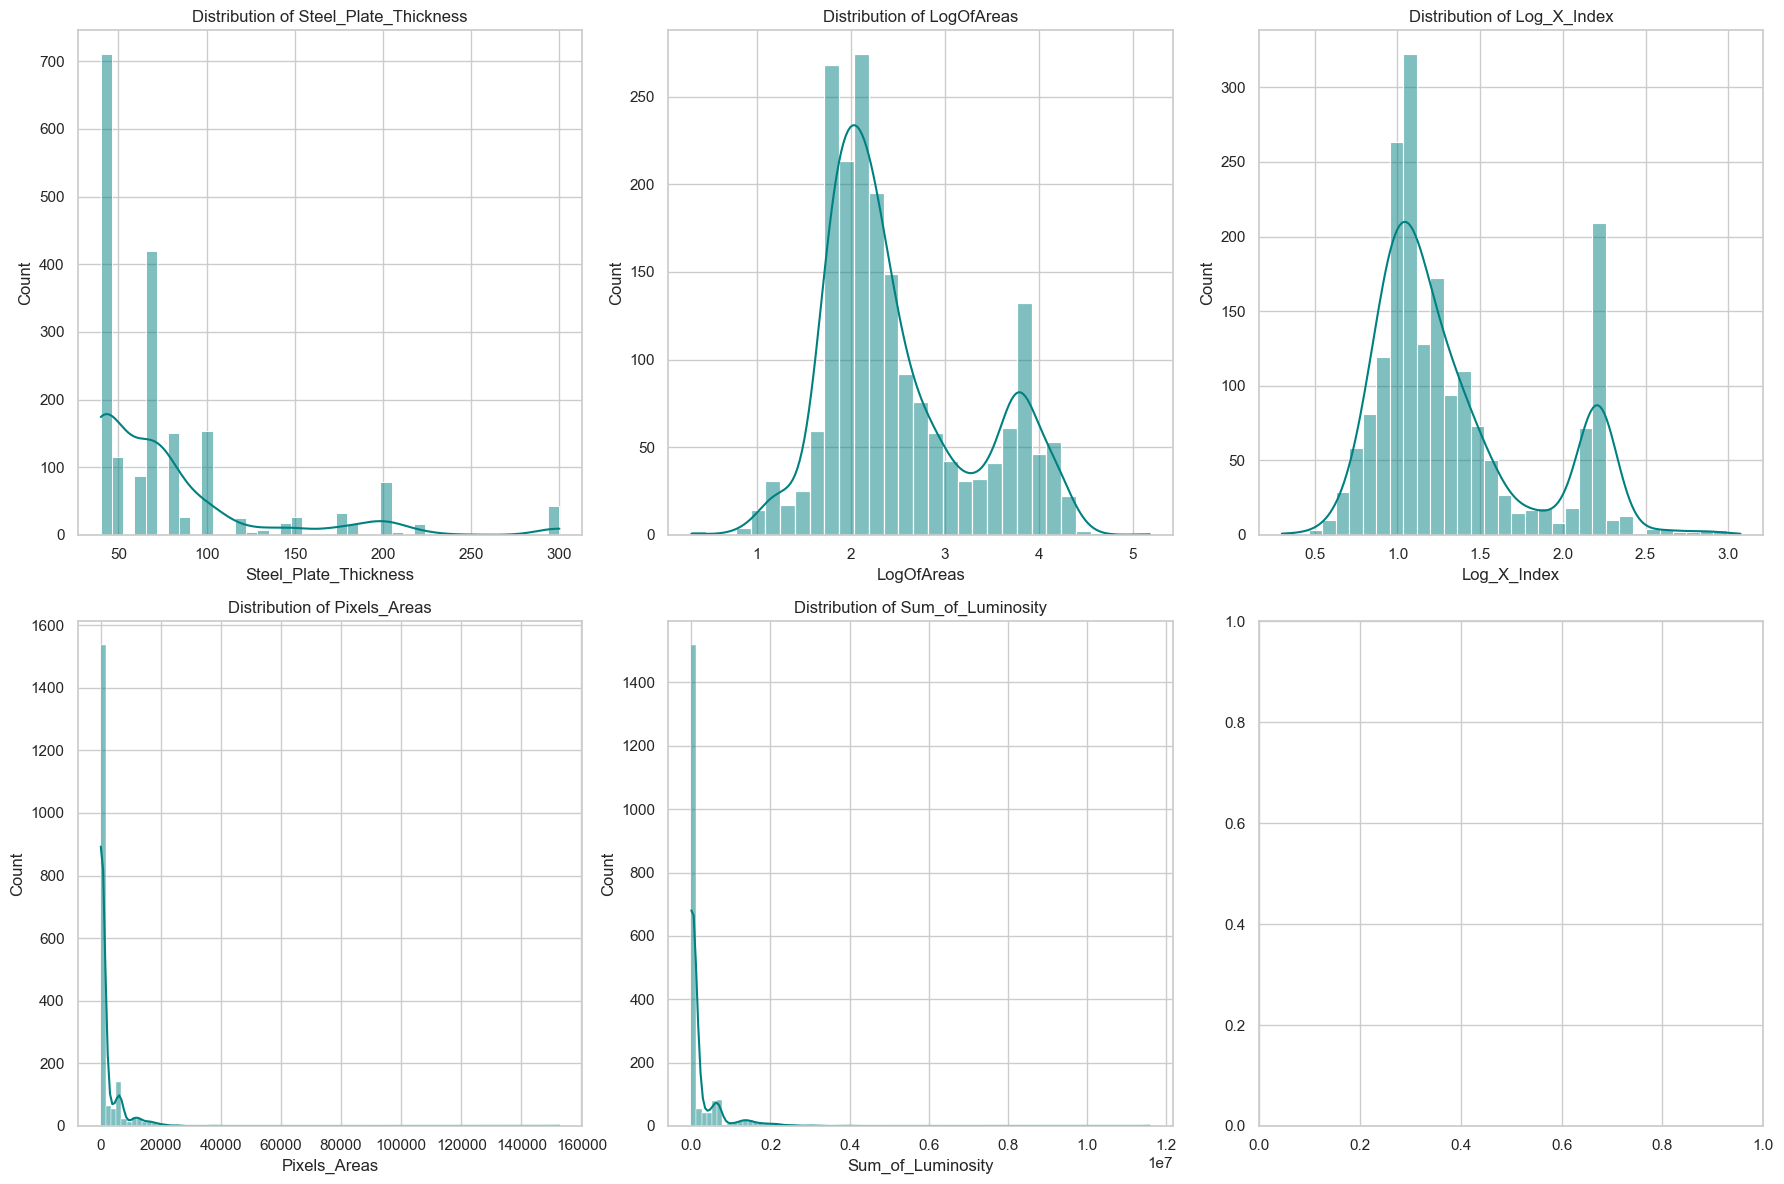

In [6]:
cols_to_plot = ['Steel_Plate_Thickness', 'LogOfAreas', 'Log_X_Index', 'Pixels_Areas', 'Sum_of_Luminosity']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

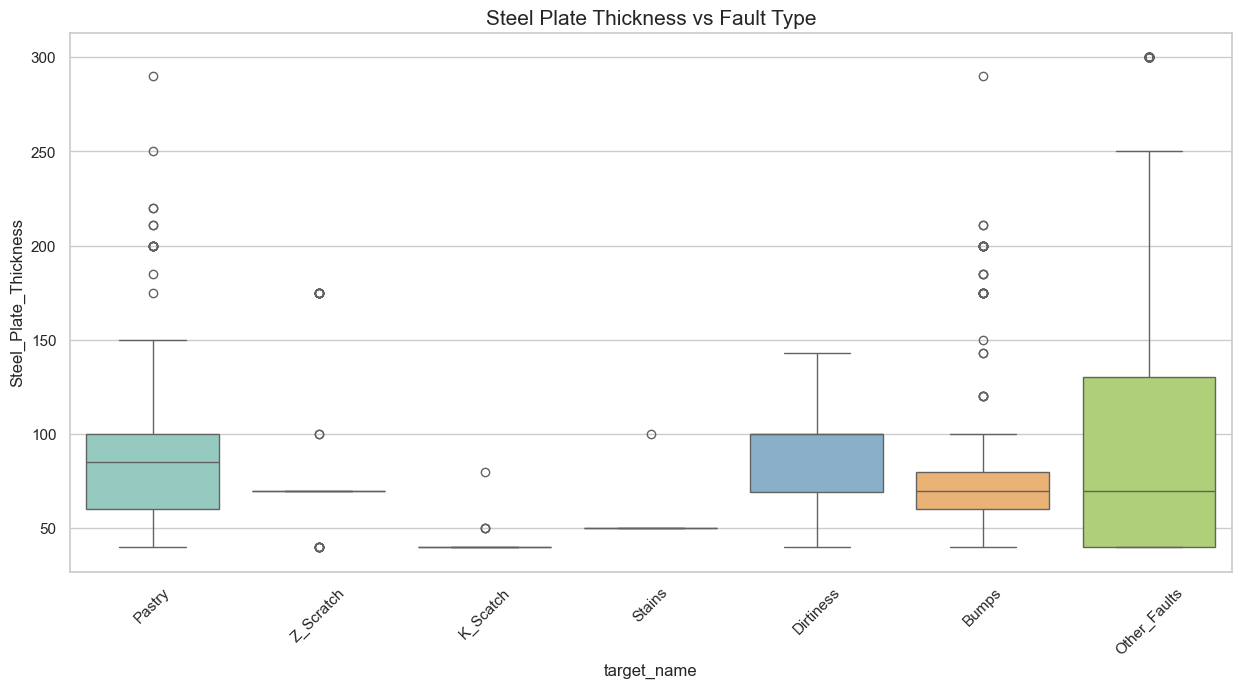

In [7]:
plt.figure(figsize=(15, 7))
sns.boxplot(x='target_name', y='Steel_Plate_Thickness', data=df, palette='Set3')
plt.title('Steel Plate Thickness vs Fault Type', fontsize=15)
plt.xticks(rotation=45)
plt.show()

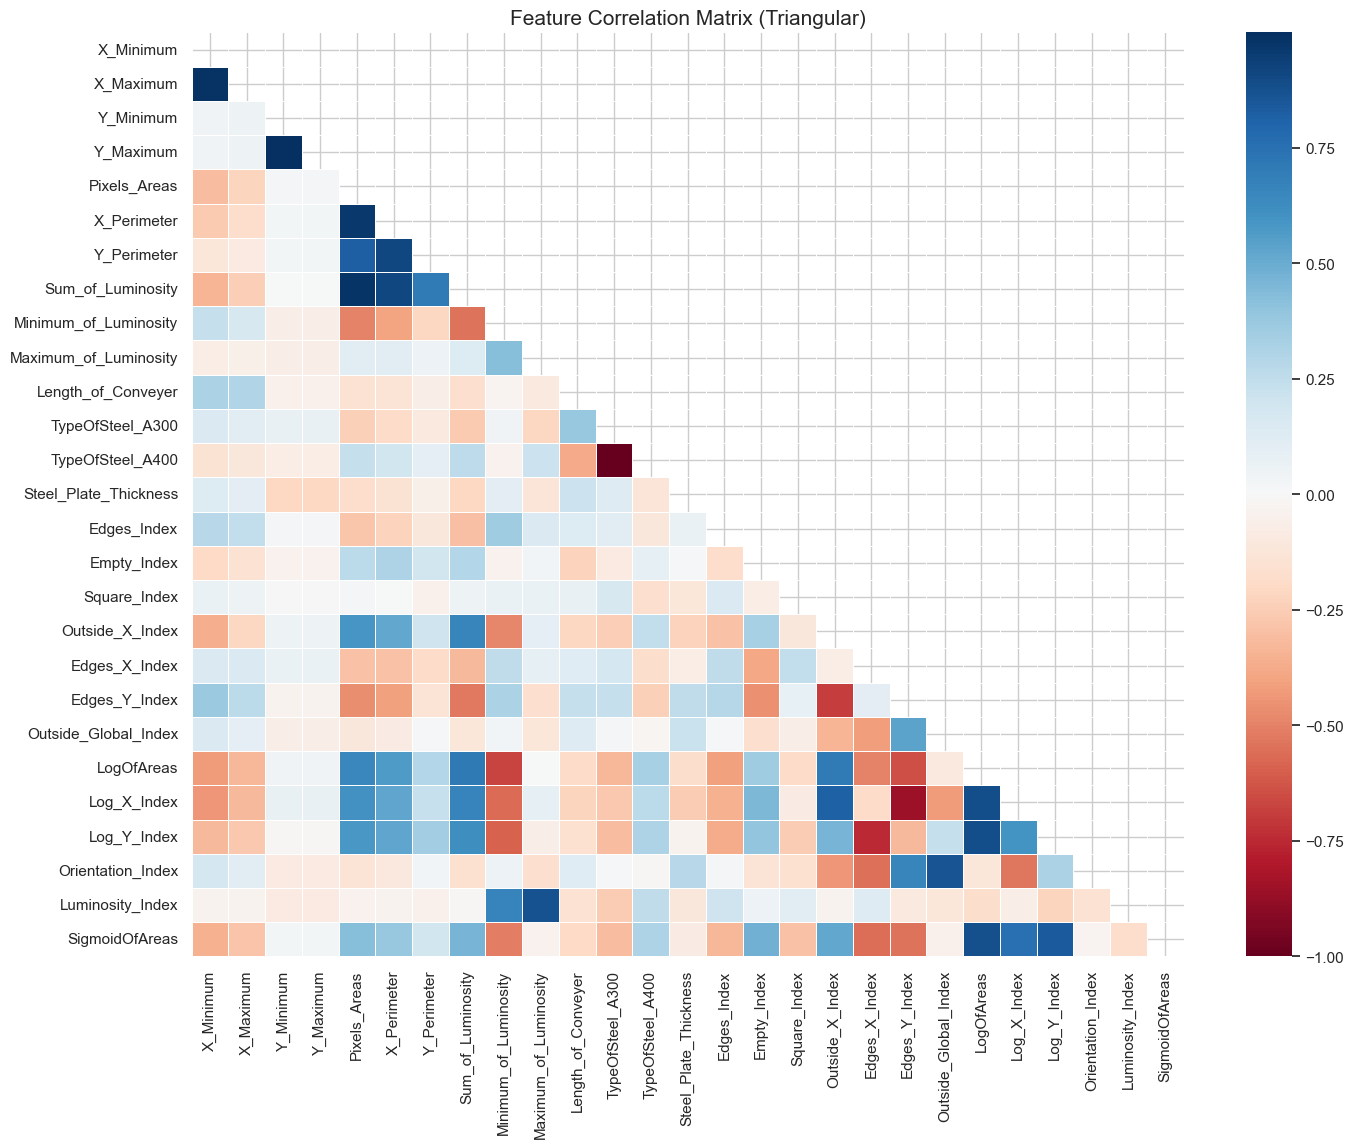

In [8]:
X = df.drop(columns=target_cols + ['id', 'target', 'target_name'])
corr = X.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu', center=0, annot=False, linewidths=.5)
plt.title('Feature Correlation Matrix (Triangular)', fontsize=15)
plt.show()

## 4. Feature Importance (Random Forest Approach)

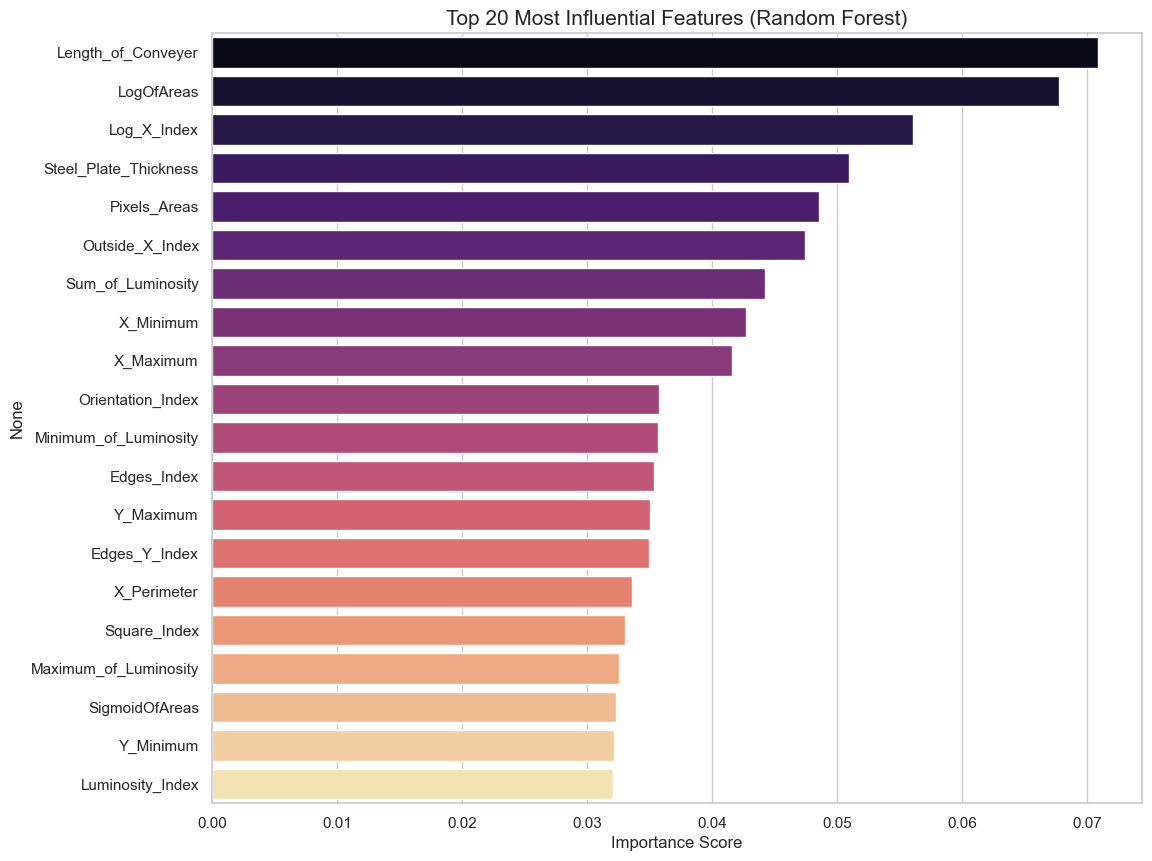

In [9]:
y = df['target']
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 10))
sns.barplot(x=importances.values[:20], y=importances.index[:20], palette='magma')
plt.title('Top 20 Most Influential Features (Random Forest)', fontsize=15)
plt.xlabel('Importance Score')
plt.show()

## 5. Model Building and Benchmarking (Baselines)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1, importance_type='gain'),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

baseline_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    baseline_results[name] = acc
    print(f"{name:20}: {acc:.4f}")

Logistic Regression : 0.5553


Random Forest       : 0.7763


XGBoost             : 0.7943


LightGBM            : 0.7866


AdaBoost            : 0.5450


## 6. Comprehensive Hyperparameter Tuning
We will tune all models using Grid Search to find the best possible performance for each architecture.

In [11]:
tuned_results = {}
best_params = {}

### Tuning Logistic Regression

In [12]:
lr_params = {'C': [0.01, 0.1, 1, 10]}
lr_grid = GridSearchCV(LogisticRegression(max_iter=5000, random_state=42), lr_params, cv=3, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train, y_train)
tuned_results['Logistic Regression'] = accuracy_score(y_test, lr_grid.predict(X_test))
best_params['Logistic Regression'] = lr_grid.best_params_
print(f"LR - Best Params: {lr_grid.best_params_}, Accuracy: {tuned_results['Logistic Regression']:.4f}")

LR - Best Params: {'C': 0.01}, Accuracy: 0.5501


### Tuning Random Forest

In [13]:
rf_params = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
tuned_results['Random Forest'] = accuracy_score(y_test, rf_grid.predict(X_test))
best_params['Random Forest'] = rf_grid.best_params_
print(f"RF - Best Params: {rf_grid.best_params_}, Accuracy: {tuned_results['Random Forest']:.4f}")

RF - Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}, Accuracy: 0.7763


### Tuning XGBoost

In [14]:
xgb_params = {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2]}
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='mlogloss'), xgb_params, cv=3, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
tuned_results['XGBoost'] = accuracy_score(y_test, xgb_grid.predict(X_test))
best_params['XGBoost'] = xgb_grid.best_params_
print(f"XGB - Best Params: {xgb_grid.best_params_}, Accuracy: {tuned_results['XGBoost']:.4f}")

XGB - Best Params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}, Accuracy: 0.7943


### Tuning LightGBM

In [15]:
lgbm_params = {'n_estimators': [100, 200], 'num_leaves': [31, 50], 'learning_rate': [0.01, 0.1, 0.2]}
lgbm_grid = GridSearchCV(LGBMClassifier(random_state=42, verbose=-1), lgbm_params, cv=3, scoring='accuracy', n_jobs=-1)
lgbm_grid.fit(X_train, y_train)
tuned_results['LightGBM'] = accuracy_score(y_test, lgbm_grid.predict(X_test))
best_params['LightGBM'] = lgbm_grid.best_params_
print(f"LGBM - Best Params: {lgbm_grid.best_params_}, Accuracy: {tuned_results['LightGBM']:.4f}")

LGBM - Best Params: {'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 31}, Accuracy: 0.7866


### Tuning AdaBoost

In [16]:
ada_params = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1.0]}
ada_grid = GridSearchCV(AdaBoostClassifier(random_state=42), ada_params, cv=3, scoring='accuracy', n_jobs=-1)
ada_grid.fit(X_train, y_train)
tuned_results['AdaBoost'] = accuracy_score(y_test, ada_grid.predict(X_test))
best_params['AdaBoost'] = ada_grid.best_params_
print(f"AdaBoost - Best Params: {ada_grid.best_params_}, Accuracy: {tuned_results['AdaBoost']:.4f}")

AdaBoost - Best Params: {'learning_rate': 1.0, 'n_estimators': 200}, Accuracy: 0.6375


## 7. Model Performance Analysis & Comparison

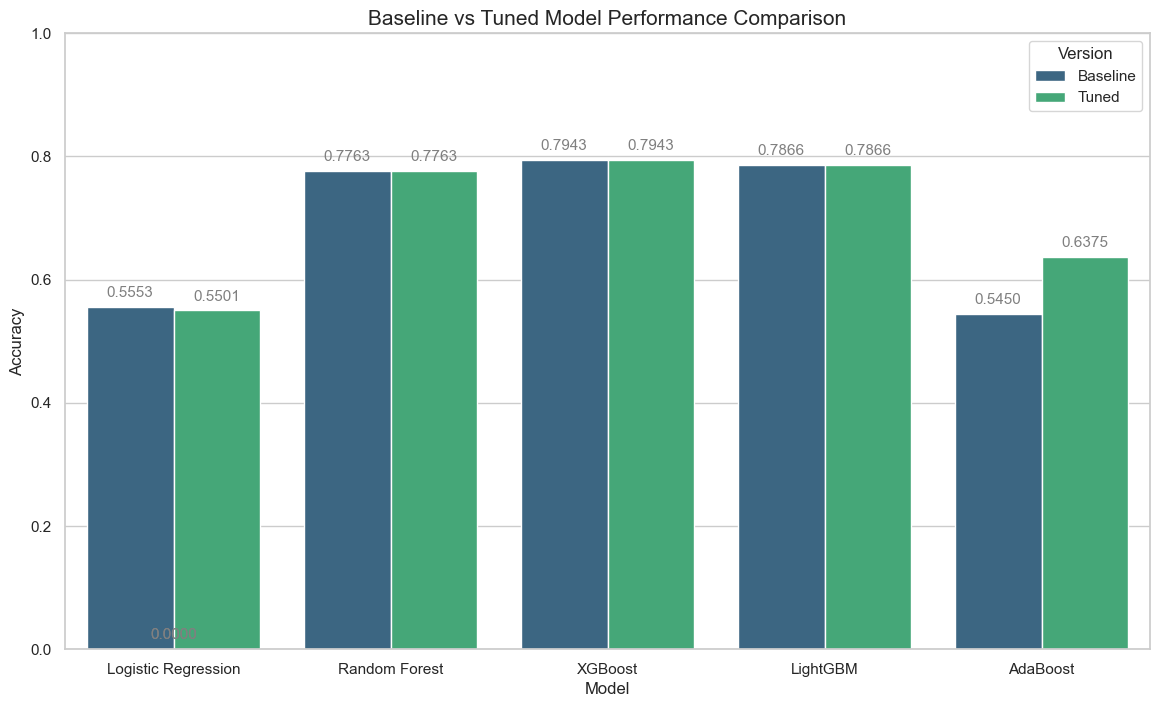

In [17]:
comparison_df = pd.DataFrame({
    'Baseline': baseline_results,
    'Tuned': tuned_results
}).reset_index().rename(columns={'index': 'Model'})

comparison_melted = comparison_df.melt(id_vars='Model', var_name='Version', value_name='Accuracy')

plt.figure(figsize=(14, 8))
sns.barplot(data=comparison_melted, x='Model', y='Accuracy', hue='Version', palette='viridis')
plt.title('Baseline vs Tuned Model Performance Comparison', fontsize=15)
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='gray', xytext=(0, 10), 
                textcoords='offset points')
plt.show()

## 8. Final Best Model Evaluation

The best overall model after tuning is: XGBoost



Final Classification Report (XGBoost):
              precision    recall  f1-score   support

      Pastry       0.60      0.62      0.61        29
   Z_Scratch       1.00      0.95      0.97        41
    K_Scatch       0.95      0.96      0.96        83
      Stains       1.00      0.92      0.96        13
   Dirtiness       0.75      0.75      0.75         8
       Bumps       0.64      0.64      0.64        72
Other_Faults       0.75      0.76      0.75       143

    accuracy                           0.79       389
   macro avg       0.81      0.80      0.81       389
weighted avg       0.80      0.79      0.80       389



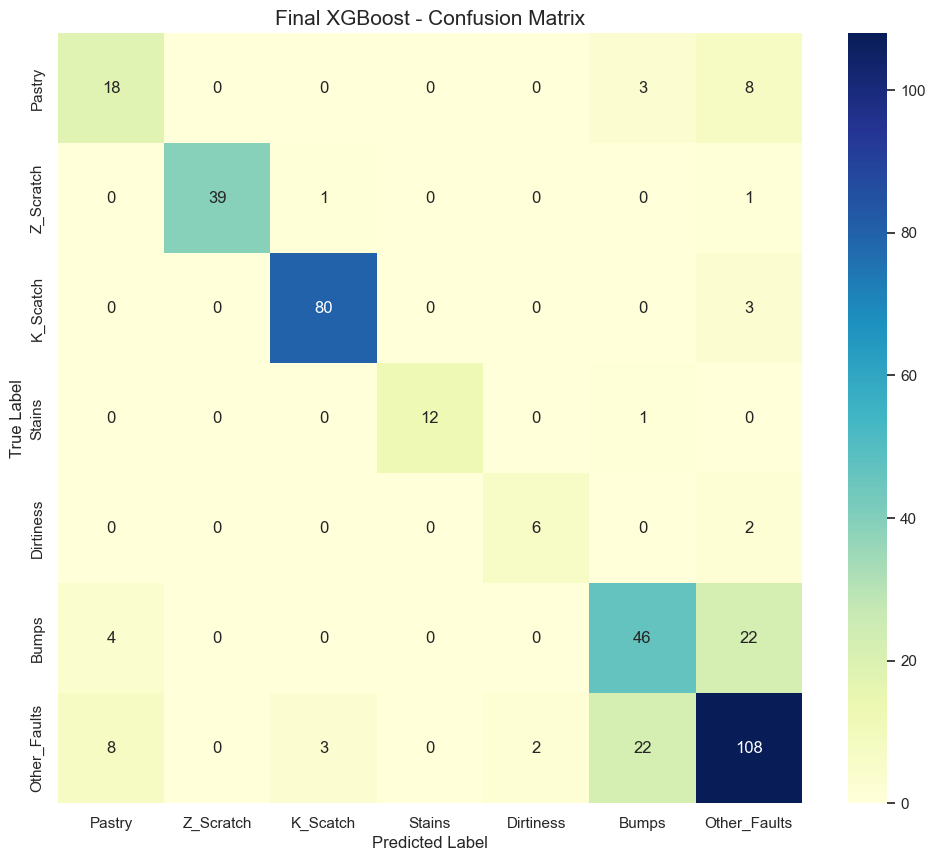

In [18]:
best_model_name = comparison_df.iloc[comparison_df['Tuned'].idxmax()]['Model']
print(f"The best overall model after tuning is: {best_model_name}")

# Get the estimator for the best model
if best_model_name == 'XGBoost': final_model = xgb_grid.best_estimator_
elif best_model_name == 'LightGBM': final_model = lgbm_grid.best_estimator_
elif best_model_name == 'Random Forest': final_model = rf_grid.best_estimator_
elif best_model_name == 'AdaBoost': final_model = ada_grid.best_estimator_
else: final_model = lr_grid.best_estimator_

y_pred = final_model.predict(X_test)

print(f"\nFinal Classification Report ({best_model_name}):")
print(classification_report(y_test, y_pred, target_names=target_cols))

plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', xticklabels=target_cols, yticklabels=target_cols, cmap='YlGnBu')
plt.title(f'Final {best_model_name} - Confusion Matrix', fontsize=15)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 9. Advanced Performance Analysis: ROC-AUC
To better understand the model's ability to distinguish between classes, we analyze the Receiver Operating Characteristic (ROC) curves and calculate the Area Under the Curve (AUC) for each fault type.

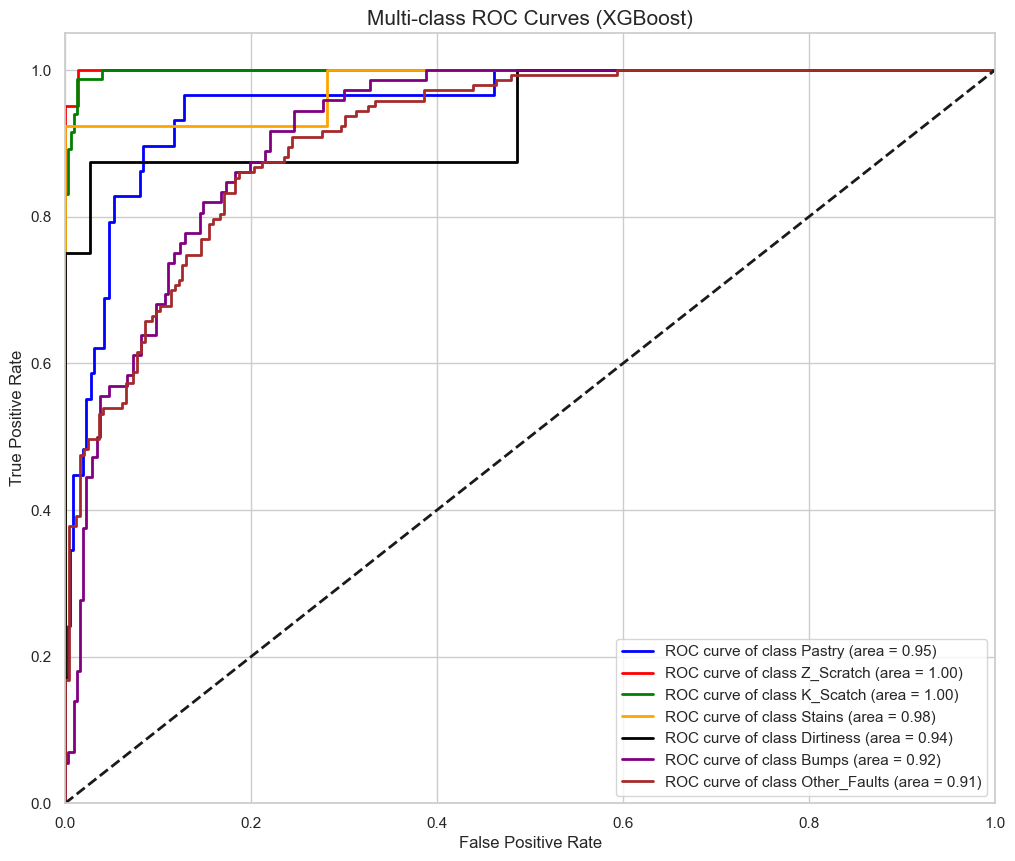

Macro ROC-AUC: 0.9568
Weighted ROC-AUC: 0.9468


In [19]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize outputs for ROC calculation
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

# Predict probabilities
y_score = final_model.predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(12, 10))
colors = cycle(['blue', 'red', 'green', 'orange', 'black', 'purple', 'brown'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {target_cols[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Multi-class ROC Curves ({best_model_name})', fontsize=15)
plt.legend(loc="lower right")
plt.show()

# Overall Macro/Weighted ROC-AUC
macro_roc_auc = roc_auc_score(y_test, y_score, multi_class='ovr', average='macro')
weighted_roc_auc = roc_auc_score(y_test, y_score, multi_class='ovr', average='weighted')
print(f"Macro ROC-AUC: {macro_roc_auc:.4f}")
print(f"Weighted ROC-AUC: {weighted_roc_auc:.4f}")